In [ ]:
!pip install yfinance xgboost lightgbm

In [ ]:
import yfinance as yf
import pandas as pd

#Change ticker ID to stock target
#Target ID can search in yahoo finance website
ticker = "BBCA.JK"

#For download all dataset
#df = yf.download(ticker, period="max")

df = yf.download(ticker, start="2020-01-01", end ="2026-03-06")

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)
    df.columns.name = None


print("Downloaded stock data for:", ticker)
print("\nData shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

# Save to CSV if needed
df.to_csv("bbca_stock_data.csv")
print("\nData saved to bbca_stock_data.csv")

[*********************100%***********************]  1 of 1 completed

Downloaded stock data for: BBCA.JK

Data shape: (1489, 5)

First few rows:
                  Close         High          Low         Open    Volume
Date                                                                    
2020-01-02  5782.699707  5860.493873  5774.055911  5787.021605  49445000
2020-01-03  5877.781738  5877.781738  5812.953263  5834.562755  47755500
2020-01-06  5821.597656  5834.563353  5782.700567  5808.631960  27300000
2020-01-07  5825.919922  5851.851316  5817.276124  5821.598023  45022500
2020-01-08  5774.056152  5830.240830  5765.412356  5765.412356  53692500

Data saved to bbca_stock_data.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style untuk visualisasi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*80)
print("PROGRAM PREDIKSI HARGA SAHAM")
print("Model: Linear Regression, XGBoost, LightGBM")
print("="*80)

PROGRAM PREDIKSI HARGA SAHAM
Model: Linear Regression, XGBoost, LightGBM



[2] DATA PREPROCESSING...

Statistik Deskriptif Data Awal:
               Open          High           Low         Close        Volume
count   1489.000000   1489.000000   1489.000000   1489.000000  1.489000e+03
mean    7454.486289   7524.150244   7383.924095   7451.784037  9.831114e+07
std     1513.363917   1517.942853   1512.009059   1515.320166  7.910957e+07
min     3846.489513   4220.747475   3738.442882   3829.201904  0.000000e+00
25%     5979.864346   6029.048312   5903.713624   5940.176270  5.998390e+07
50%     7683.146278   7789.933082   7630.489538   7723.939941  8.082900e+07
75%     8568.357775   8618.030041   8493.850200   8559.748047  1.121112e+08
max    10453.046259  10500.997070  10333.171875  10500.997070  1.432993e+09

Membuat indikator teknikal...
✓ Indikator teknikal berhasil dihitung
  - SMA (5, 15, 30 hari)
  - EMA (9 hari)
  - RSI (14 periode)
  - MACD & Signal

Baris dengan NaN dihapus: 29 baris
Data tersisa: 1460 baris

Membuat visualisasi indikator teknikal seca

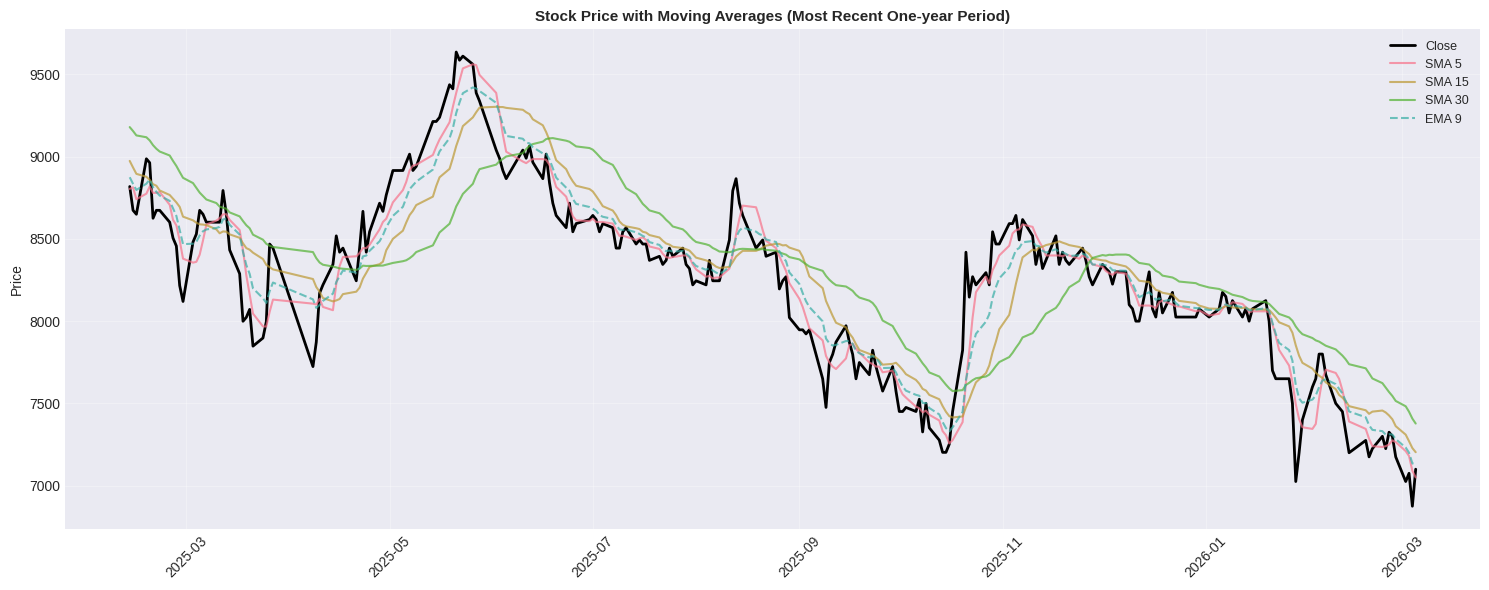

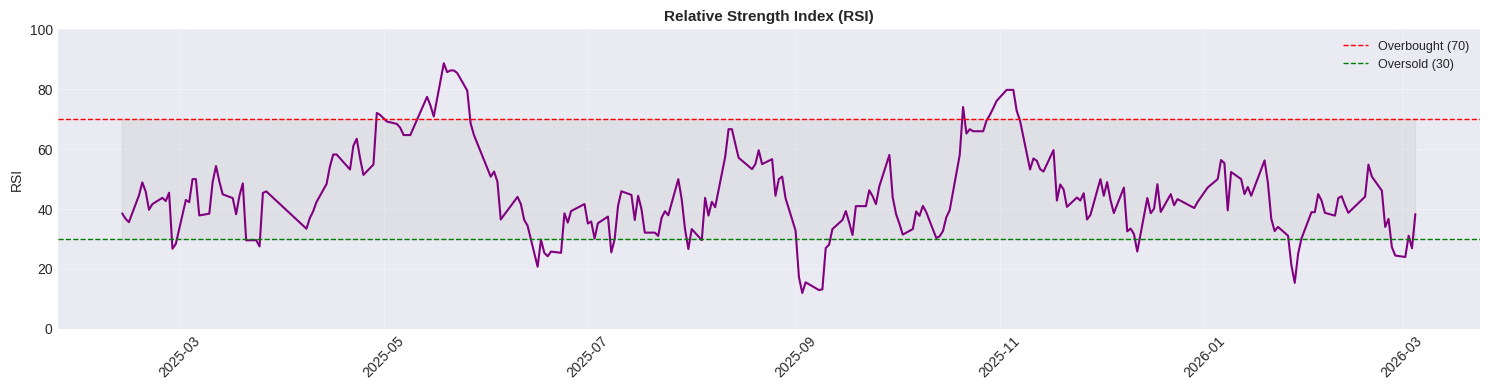

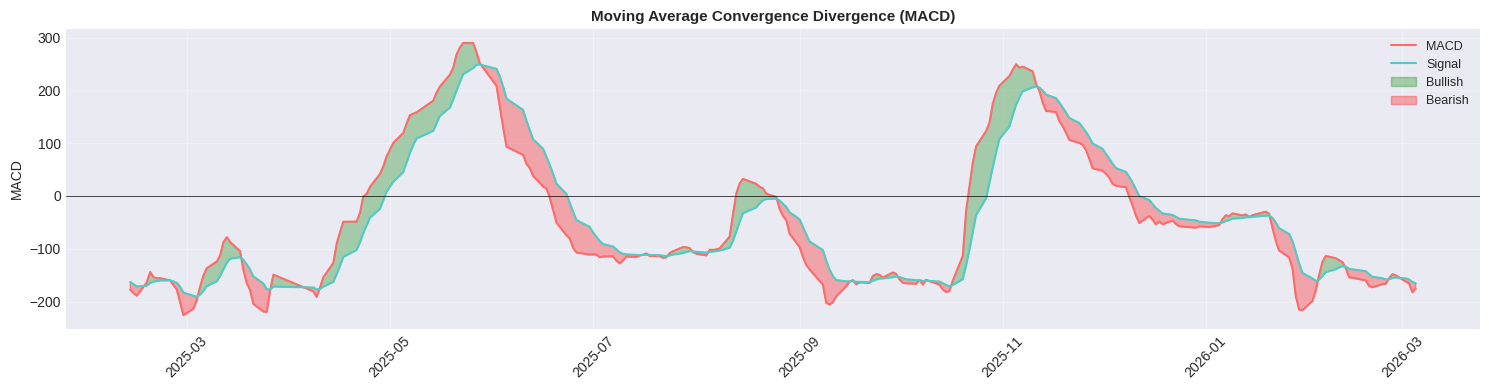

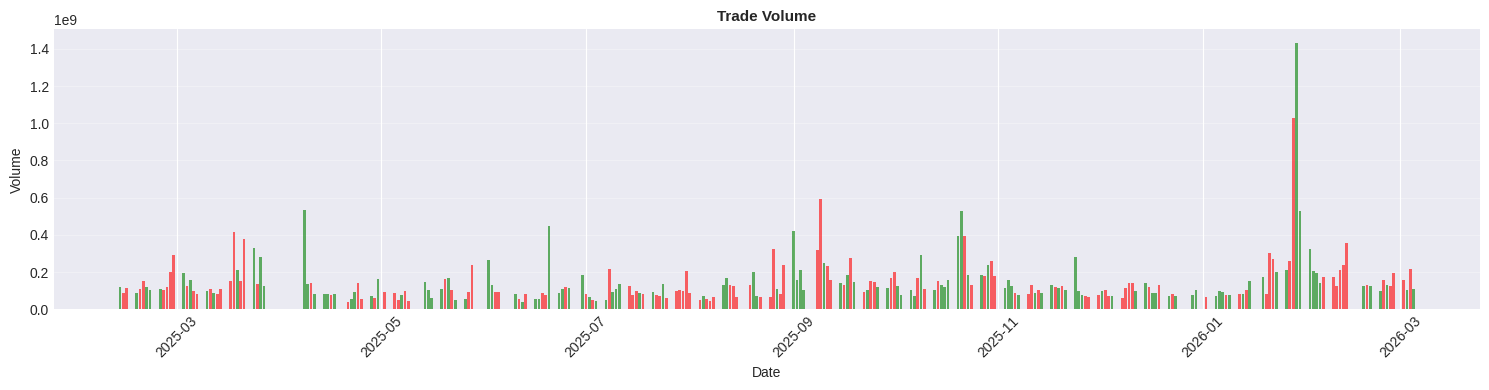


FITUR UNTUK PREDIKSI:
 1. Open
 2. High
 3. Low
 4. Volume
 5. SMA_5
 6. SMA_15
 7. SMA_30
 8. EMA_9
 9. RSI
10. MACD
11. MACD_Signal

Mendeteksi outliers...


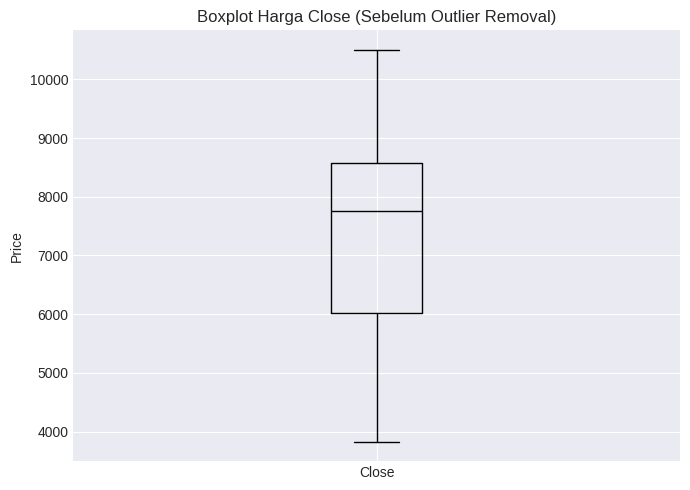

  Close: Lower=2210.13, Upper=12389.18
         Outliers terdeteksi: 0

✓ Total outliers dihapus: 0 baris (0.00%)
✓ Data bersih tersisa: 1460 baris


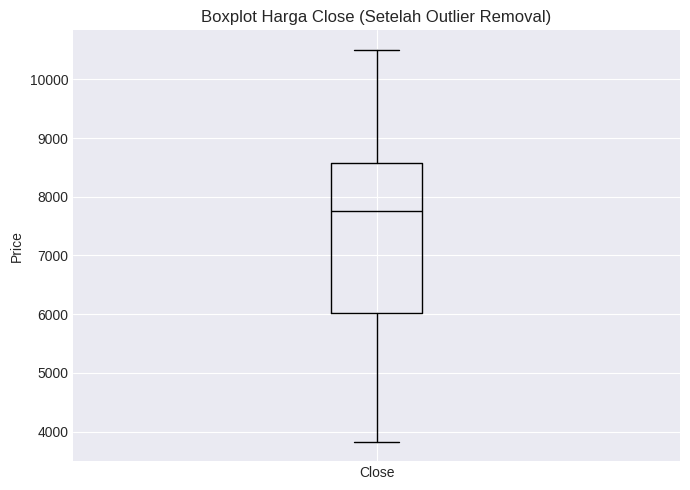


Membuat heatmap korelasi...


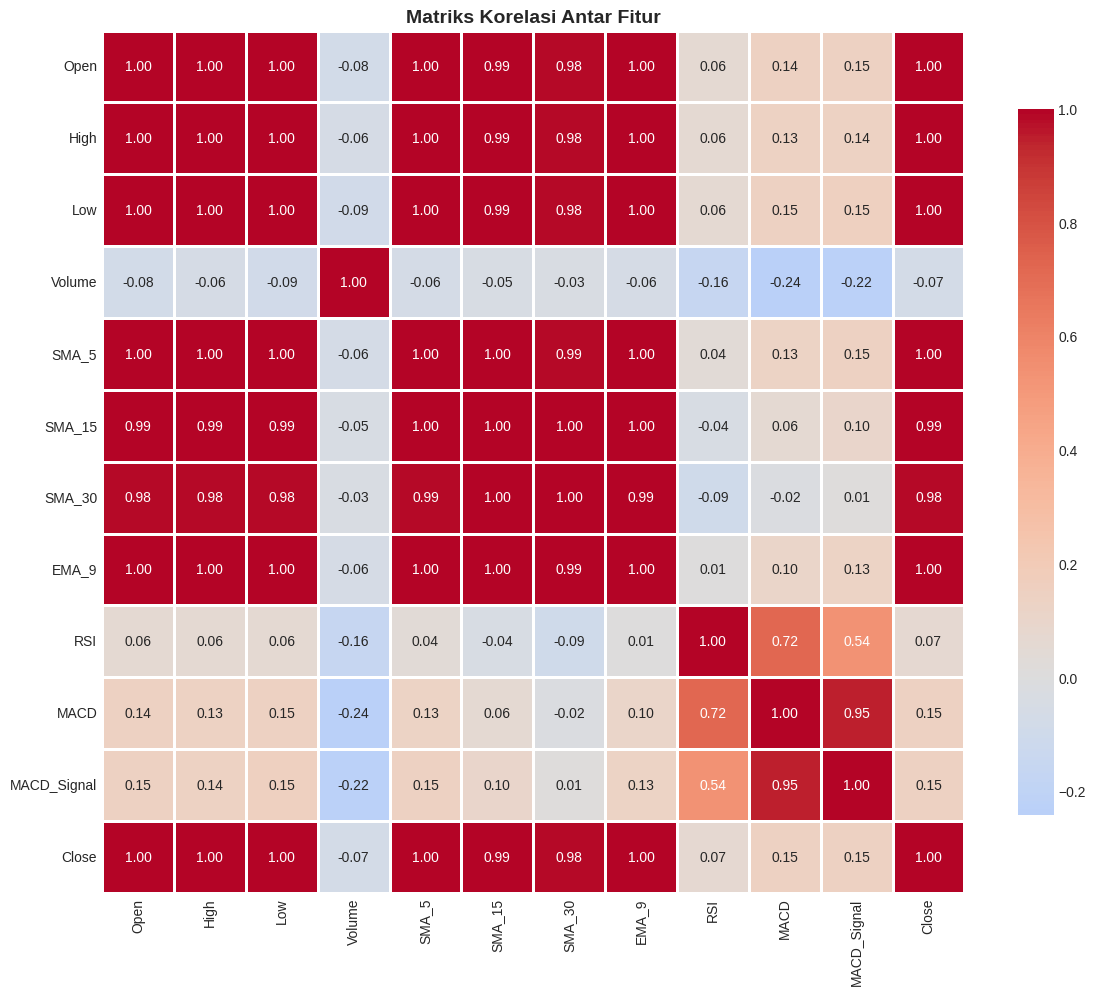


Korelasi dengan Harga Close:
  High           :  0.999
  Low            :  0.999
  Open           :  0.998
  SMA_5          :  0.997
  EMA_9          :  0.996
  SMA_15         :  0.990
  SMA_30         :  0.981
  MACD_Signal    :  0.149
  MACD           :  0.145
  RSI            :  0.070
  Volume         : -0.071

PREPROCESSING SELESAI!


In [ ]:
print("\n[2] DATA PREPROCESSING...")

# Reset the index to make 'Date' a regular column again
df = df.reset_index()

# Convert Date ke datetime (this might be redundant if the index was already datetime,
# but it ensures the column is of datetime type if reset_index changed its dtype)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Simpan kolom Date untuk visualisasi
df_dates = df['Date'].copy()

# Statistik deskriptif data awal
print("\nStatistik Deskriptif Data Awal:")
print(df[['Open', 'High', 'Low', 'Close', 'Volume']].describe())

# Membuat fitur teknikal berdasarkan jurnal (Jange, 2022)
print("\nMembuat indikator teknikal...")

def calculate_sma(data, window):
    """Simple Moving Average"""
    return data.rolling(window=window).mean()

def calculate_ema(data, span):
    """Exponential Moving Average"""
    return data.ewm(span=span, adjust=False).mean()

def calculate_rsi(data, period=14):
    """Relative Strength Index"""
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

def calculate_macd(data, fast=12, slow=26, signal=9):
    """Moving Average Convergence Divergence"""
    ema_fast = data.ewm(span=fast, adjust=False).mean()
    ema_slow = data.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    macd_signal = macd.ewm(span=signal, adjust=False).mean()
    return macd, macd_signal

# Hitung indikator teknikal
df['SMA_5'] = calculate_sma(df['Close'], 5)
df['SMA_15'] = calculate_sma(df['Close'], 15)
df['SMA_30'] = calculate_sma(df['Close'], 30)
df['EMA_9'] = calculate_ema(df['Close'], 9)
df['RSI'] = calculate_rsi(df['Close'])
df['MACD'], df['MACD_Signal'] = calculate_macd(df['Close'])

print("✓ Indikator teknikal berhasil dihitung")
print(f"  - SMA (5, 15, 30 hari)")
print(f"  - EMA (9 hari)")
print(f"  - RSI (14 periode)")
print(f"  - MACD & Signal")

# Hapus baris dengan NaN
rows_before = len(df)
df = df.dropna().reset_index(drop=True)
print(f"\nBaris dengan NaN dihapus: {rows_before - len(df)} baris")
print(f"Data tersisa: {len(df)} baris")

# Visualisasi indikator teknikal
print("\nMembuat visualisasi indikator teknikal secara terpisah...")

# Ambil data 1 tahun terakhir untuk visualisasi
plot_range = slice(-252, None)  # 1 tahun terakhir
date_range = df['Date'].iloc[plot_range]

# Plot 1: Harga Close dengan SMA dan EMA
plt.figure(figsize=(15, 6))
plt.plot(date_range, df['Close'].iloc[plot_range],
         label='Close', linewidth=2, color='black')
plt.plot(date_range, df['SMA_5'].iloc[plot_range],
         label='SMA 5', linewidth=1.5, alpha=0.7)
plt.plot(date_range, df['SMA_15'].iloc[plot_range],
         label='SMA 15', linewidth=1.5, alpha=0.7)
plt.plot(date_range, df['SMA_30'].iloc[plot_range],
         label='SMA 30', linewidth=1.5, alpha=0.7)
plt.plot(date_range, df['EMA_9'].iloc[plot_range],
         label='EMA 9', linewidth=1.5, linestyle='--', alpha=0.7)
plt.ylabel('Price', fontsize=10)
plt.title('Stock Price with Moving Averages (Most Recent One-year Period)',
          fontsize=11, fontweight='bold')
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('stock_price_ma.eps', format='eps')
plt.show()

# Plot 2: RSI
plt.figure(figsize=(15, 4))
plt.plot(date_range, df['RSI'].iloc[plot_range],
         linewidth=1.5, color='purple')
plt.axhline(y=70, color='r', linestyle='--', label='Overbought (70)', linewidth=1)
plt.axhline(y=30, color='g', linestyle='--', label='Oversold (30)', linewidth=1)
plt.fill_between(date_range, 30, 70, alpha=0.1, color='gray')
plt.ylabel('RSI', fontsize=10)
plt.title('Relative Strength Index (RSI)', fontsize=11, fontweight='bold')
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)
plt.ylim([0, 100])
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('rsi_indicator.eps', format='eps')
plt.show()

# Plot 3: MACD
plt.figure(figsize=(15, 4))
plt.plot(date_range, df['MACD'].iloc[plot_range],
         label='MACD', linewidth=1.5, color='#FF6B6B')
plt.plot(date_range, df['MACD_Signal'].iloc[plot_range],
         label='Signal', linewidth=1.5, color='#4ECDC4')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Fill area untuk bullish dan bearish
macd_data = df['MACD'].iloc[plot_range].values
signal_data = df['MACD_Signal'].iloc[plot_range].values
plt.fill_between(date_range, macd_data, signal_data,
                 where=(macd_data >= signal_data),
                 color='green', alpha=0.3, label='Bullish', interpolate=True)
plt.fill_between(date_range, macd_data, signal_data,
                 where=(macd_data < signal_data),
                 color='red', alpha=0.3, label='Bearish', interpolate=True)

plt.ylabel('MACD', fontsize=10)
plt.title('Moving Average Convergence Divergence (MACD)',
          fontsize=11, fontweight='bold')
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('macd_indicator.eps', format='eps')
plt.show()

# Plot 4: Volume
plt.figure(figsize=(15, 4))
colors = ['green' if df['Close'].iloc[i] >= df['Open'].iloc[i]
          else 'red' for i in df.iloc[plot_range].index]
plt.bar(date_range, df['Volume'].iloc[plot_range],
        color=colors, alpha=0.6, width=0.8)
plt.ylabel('Volume', fontsize=10)
plt.xlabel('Date', fontsize=10)
plt.title('Trade Volume', fontsize=11, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)

# Format angka pada axis y untuk volume
plt.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

plt.tight_layout()
plt.savefig('trade_volume.eps', format='eps')
plt.show()

# Fitur yang digunakan
print("\n" + "="*60)
print("FITUR UNTUK PREDIKSI:")
print("="*60)
feature_cols = ['Open', 'High', 'Low', 'Volume', 'SMA_5', 'SMA_15',
                'SMA_30', 'EMA_9', 'RSI', 'MACD', 'MACD_Signal']
for i, feat in enumerate(feature_cols, 1):
    print(f"{i:2d}. {feat}")
print("="*60)

# Deteksi dan handling outliers (berdasarkan Andrika, 2025)
print("\nMendeteksi outliers...")

# Visualisasi boxplot sebelum menghapus outliers
plt.figure(figsize=(7, 5))
df.boxplot(column=['Close'], color='black')
plt.title('Boxplot Harga Close (Sebelum Outlier Removal)')
plt.ylabel('Price')
plt.tight_layout()
plt.savefig('boxplot_before_outlier_removal.eps', format='eps')
plt.show()

def remove_outliers(df, columns):
    """Remove outliers menggunakan IQR method"""
    df_clean = df.copy()
    outlier_indices = set()

    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Simpan indeks outlier
        outlier_idx = df_clean[(df_clean[col] < lower_bound) |
                              (df_clean[col] > upper_bound)].index
        outlier_indices.update(outlier_idx)

        print(f"  {col}: Lower={lower_bound:.2f}, Upper={upper_bound:.2f}")
        print(f"         Outliers terdeteksi: {len(outlier_idx)}")

    # Hapus semua outlier
    df_clean = df_clean.drop(index=list(outlier_indices))
    df_clean = df_clean.reset_index(drop=True)

    return df_clean

df_original_len = len(df)
df = remove_outliers(df, ['Close'])
outliers_removed = df_original_len - len(df)

print(f"\n✓ Total outliers dihapus: {outliers_removed} baris ({outliers_removed/df_original_len*100:.2f}%)")
print(f"✓ Data bersih tersisa: {len(df)} baris")

# Boxplot setelah menghapus outliers
plt.figure(figsize=(7, 5))
df.boxplot(column=['Close'], color='black')
plt.title('Boxplot Harga Close (Setelah Outlier Removal)')
plt.ylabel('Price')
plt.tight_layout()
plt.savefig('boxplot_after_outlier_removal.eps', format='eps')
plt.show()

# Korelasi antar fitur
print("\nMembuat heatmap korelasi...")
correlation_matrix = df[feature_cols + ['Close']].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriks Korelasi Antar Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.eps', format='eps') # Save the plot as eps
plt.show()

# Tampilkan korelasi tertinggi dengan Close
print("\nKorelasi dengan Harga Close:")
close_corr = correlation_matrix['Close'].sort_values(ascending=False)
for feat, corr in close_corr.items():
    if feat != 'Close':
        print(f"  {feat:15s}: {corr:6.3f}")

print("\n" + "="*60)
print("PREPROCESSING SELESAI!")
print("="*60)


In [ ]:
print("\n[3] SPLITTING DATA...")

# Fitur dan target
X = df[feature_cols]
y = df['Close']

# Split 80:20 (berdasarkan Andrika, 2025)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

print(f"Training set: {len(X_train)} samples")
print(f"Testing set: {len(X_test)} samples")

# Normalisasi data menggunakan MinMaxScaler
print("\nNormalisasi data...")
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



[3] SPLITTING DATA...
Training set: 1168 samples
Testing set: 292 samples

Normalisasi data...


In [ ]:
%%time
print("\n[4] MODEL TRAINING...")

results = {}

# ---------------------------------------------------------------------------
# 5.1 LINEAR REGRESSION
# ---------------------------------------------------------------------------
print("\n--- Linear Regression ---")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluasi
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mape_lr = np.mean(np.abs((y_test - y_pred_lr) / y_test)) * 100
r2_lr = r2_score(y_test, y_pred_lr)

results['Linear Regression'] = {
    'model': lr_model,
    'predictions': y_pred_lr,
    'RMSE': rmse_lr,
    'MAE': mae_lr,
    'MAPE': mape_lr,
    'R2': r2_lr
}

print(f"RMSE: {rmse_lr:.4f}")
print(f"MAE: {mae_lr:.4f}")
print(f"MAPE: {mape_lr:.4f}%")
print(f"R²: {r2_lr:.4f}")



[4] MODEL TRAINING...

--- Linear Regression ---
RMSE: 53.1336
MAE: 40.9742
MAPE: 0.4915%
R²: 0.9932
CPU times: user 21 ms, sys: 955 µs, total: 21.9 ms
Wall time: 21.9 ms


In [ ]:
%%time
# ---------------------------------------------------------------------------
# 5.2 XGBOOST (berdasarkan Jange, 2022 & Zhang, 2022)
# ---------------------------------------------------------------------------
print("\n--- XGBoost ---")

# Hyperparameter tuning menggunakan GridSearchCV
xgb_params = {
    'n_estimators': [100, 200, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 8, 12],
    'gamma': [0.001, 0.01]
}

print("Melakukan Grid Search untuk hyperparameter tuning...")
xgb_model = xgb.XGBRegressor(random_state=42, objective='reg:squarederror')
xgb_grid = GridSearchCV(xgb_model, xgb_params, cv=3,
                        n_jobs=-1, verbose=0)
xgb_grid.fit(X_train_scaled, y_train)

print(f"Best parameters: {xgb_grid.best_params_}")

# Prediksi dengan model terbaik
y_pred_xgb = xgb_grid.best_estimator_.predict(X_test_scaled)

# Evaluasi
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mape_xgb = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100
r2_xgb = r2_score(y_test, y_pred_xgb)

results['XGBoost'] = {
    'model': xgb_grid.best_estimator_,
    'predictions': y_pred_xgb,
    'RMSE': rmse_xgb,
    'MAE': mae_xgb,
    'MAPE': mape_xgb,
    'R2': r2_xgb
}

print(f"RMSE: {rmse_xgb:.4f}")
print(f"MAE: {mae_xgb:.4f}")
print(f"MAPE: {mape_xgb:.4f}%")
print(f"R²: {r2_xgb:.4f}")


--- XGBoost ---
Melakukan Grid Search untuk hyperparameter tuning...
Best parameters: {'gamma': 0.001, 'learning_rate': 0.05, 'max_depth': 12, 'n_estimators': 400}
RMSE: 82.1257
MAE: 64.4016
MAPE: 0.7720%
R²: 0.9837
CPU times: user 12.6 s, sys: 207 ms, total: 12.8 s
Wall time: 2min 43s


In [ ]:
%%time
print("\n--- LightGBM ---")

# Hyperparameter tuning
lgb_params = {
    'n_estimators': [100, 200, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 8, 12],
    'num_leaves': [31, 50, 70],
    'boosting_type': ['gbdt', 'dart']
}

print("Melakukan Grid Search untuk hyperparameter tuning...")
lgb_model = lgb.LGBMRegressor(random_state=42, verbose=-1)
lgb_grid = GridSearchCV(lgb_model, lgb_params, cv=3,
                        n_jobs=-1, verbose=0)
lgb_grid.fit(X_train_scaled, y_train)

print(f"Best parameters: {lgb_grid.best_params_}")

# Prediksi dengan model terbaik
y_pred_lgb = lgb_grid.best_estimator_.predict(X_test_scaled)

# Evaluasi
rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
mape_lgb = np.mean(np.abs((y_test - y_pred_lgb) / y_test)) * 100
r2_lgb = r2_score(y_test, y_pred_lgb)

results['LightGBM'] = {
    'model': lgb_grid.best_estimator_,
    'predictions': y_pred_lgb,
    'RMSE': rmse_lgb,
    'MAE': mae_lgb,
    'MAPE': mape_lgb,
    'R2': r2_lgb
}

print(f"RMSE: {rmse_lgb:.4f}")
print(f"MAE: {mae_lgb:.4f}")
print(f"MAPE: {mape_lgb:.4f}%")
print(f"R²: {r2_lgb:.4f}")


--- LightGBM ---
Melakukan Grid Search untuk hyperparameter tuning...
Best parameters: {'boosting_type': 'gbdt', 'learning_rate': 0.1, 'max_depth': 12, 'n_estimators': 400, 'num_leaves': 50}
RMSE: 80.6057
MAE: 62.8028
MAPE: 0.7585%
R²: 0.9843
CPU times: user 1.77 s, sys: 145 ms, total: 1.92 s
Wall time: 1min 37s



PERBANDINGAN HASIL MODEL

            Model      RMSE  MAPE (%)       R²
Linear Regression 53.133610  0.491482 0.993171
          XGBoost 82.125742  0.772014 0.983686
         LightGBM 80.605739  0.758515 0.984284

🏆 MODEL TERBAIK: Linear Regression
   (Berdasarkan RMSE terendah)

[5] MEMBUAT VISUALISASI...


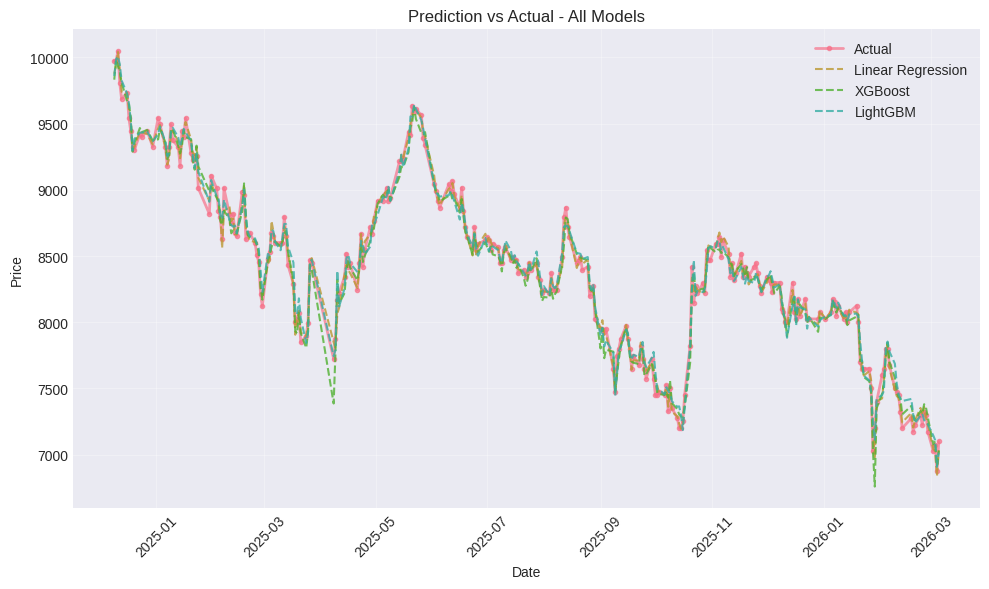

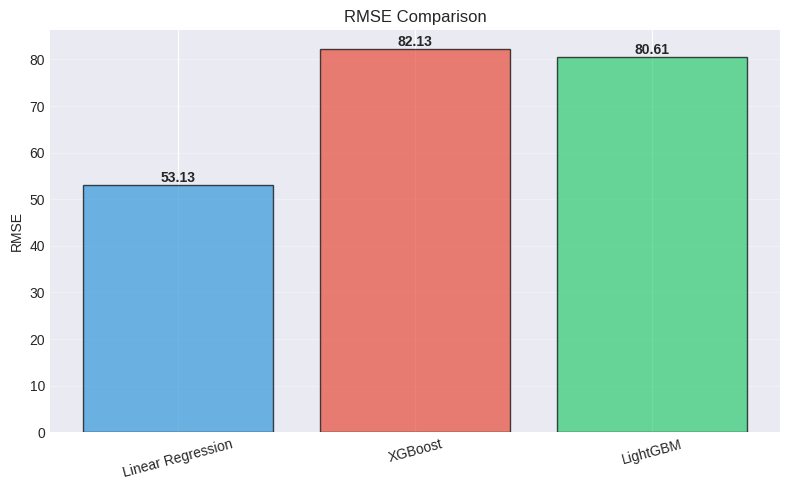

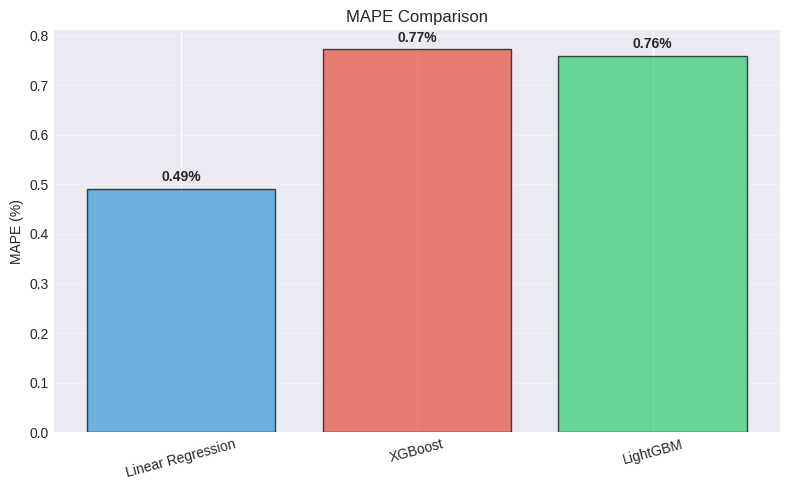

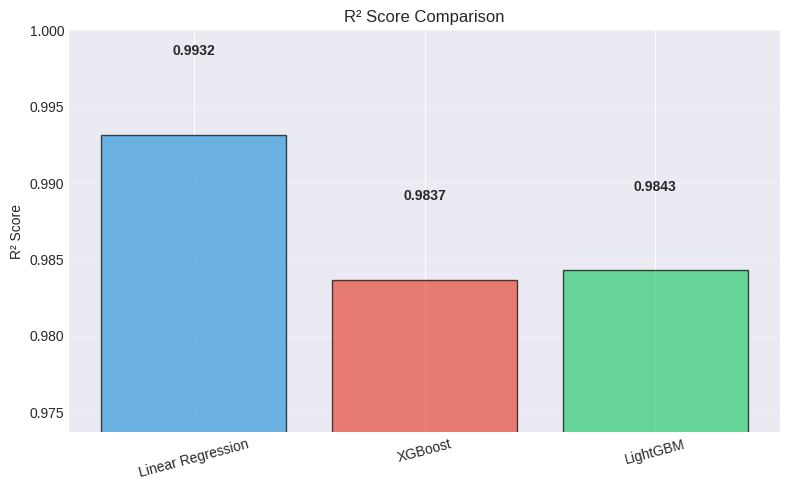

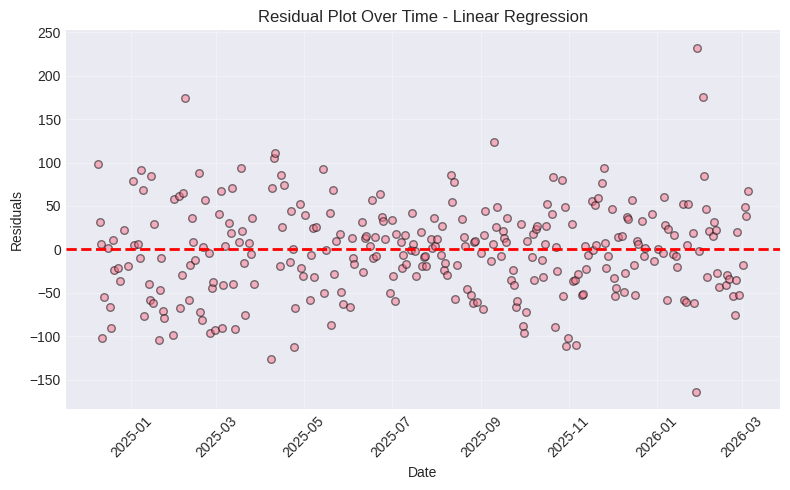

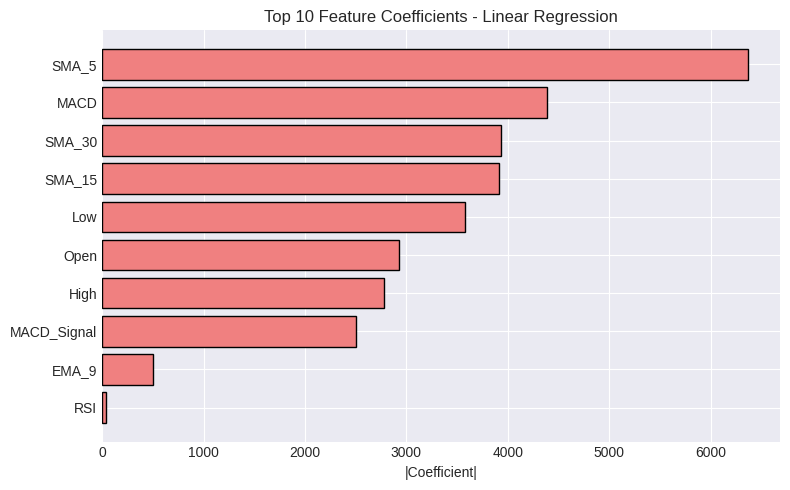

In [ ]:
print("\n" + "="*80)
print("PERBANDINGAN HASIL MODEL")
print("="*80)

# Buat tabel perbandingan
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'RMSE': [results[m]['RMSE'] for m in results.keys()],
    'MAPE (%)': [results[m]['MAPE'] for m in results.keys()],
    'R²': [results[m]['R2'] for m in results.keys()]
})

print("\n" + comparison_df.to_string(index=False))

# Tentukan model terbaik
best_model_name = comparison_df.loc[comparison_df['RMSE'].idxmin(), 'Model']
print(f"\n🏆 MODEL TERBAIK: {best_model_name}")
print(f"   (Berdasarkan RMSE terendah)")

# ============================================================================
# 7. VISUALISASI
# ============================================================================
print("\n[5] MEMBUAT VISUALISASI...")

# Ambil tanggal untuk data test
test_dates = df.loc[X_test.index, 'Date'].values

# Plot 1: Perbandingan Prediksi vs Aktual
plt.figure(figsize=(10, 6))
plt.plot(test_dates, y_test.values, label='Actual', linewidth=2, marker='o',
         markersize=3, alpha=0.7)
plt.plot(test_dates, y_pred_lr, label='Linear Regression', linewidth=1.5,
         linestyle='--', alpha=0.8)
plt.plot(test_dates, y_pred_xgb, label='XGBoost', linewidth=1.5,
         linestyle='--', alpha=0.8)
plt.plot(test_dates, y_pred_lgb, label='LightGBM', linewidth=1.5,
         linestyle='--', alpha=0.8)
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Prediction vs Actual - All Models')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('prediction_vs_actual.eps', format='eps')
plt.show()

# Plot 2: Bar chart perbandingan RMSE
plt.figure(figsize=(8, 5))
models = list(results.keys())
rmse_values = [results[m]['RMSE'] for m in models]
colors = ['#3498db', '#e74c3c', '#2ecc71']
bars = plt.bar(models, rmse_values, color=colors, alpha=0.7, edgecolor='black')
plt.ylabel('RMSE')
plt.title('RMSE Comparison')
plt.xticks(rotation=15)
for bar, val in zip(bars, rmse_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('rmse_comparison.eps', format='eps')
plt.show()

# Plot 3: Bar chart perbandingan MAPE
plt.figure(figsize=(8, 5))
mape_values = [results[m]['MAPE'] for m in models]
bars = plt.bar(models, mape_values, color=colors, alpha=0.7, edgecolor='black')
plt.ylabel('MAPE (%)')
plt.title('MAPE Comparison')
plt.xticks(rotation=15)
for bar, val in zip(bars, mape_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}%', ha='center', va='bottom', fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('mape_comparison.eps', format='eps')
plt.show()

# Plot 4: Bar chart perbandingan R²
plt.figure(figsize=(8, 5))
r2_values = [results[m]['R2'] for m in models]
bars = plt.bar(models, r2_values, color=colors, alpha=0.7, edgecolor='black')
plt.ylabel('R² Score')
plt.title('R² Score Comparison')
plt.xticks(rotation=15)
plt.ylim([min(r2_values) - 0.01, 1.0])
for bar, val in zip(bars, r2_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('r2_comparison.eps', format='eps')
plt.show()

# Plot 5: Residual plot untuk model terbaik
plt.figure(figsize=(8, 5))
best_predictions = results[best_model_name]['predictions']
residuals = y_test.values - best_predictions
plt.scatter(test_dates, residuals, alpha=0.5, edgecolors='black', s=30)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.title(f'Residual Plot Over Time - {best_model_name}')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('residual_plot.eps', format='eps')
plt.show()

# Plot 6: Feature importance untuk model terbaik (jika applicable)
plt.figure(figsize=(8, 5))
if best_model_name in ['XGBoost', 'LightGBM']:
    best_model = results[best_model_name]['model']
    if hasattr(best_model, 'feature_importances_'):
        importances = best_model.feature_importances_
        indices = np.argsort(importances)[::-1][:10]  # Top 10 features
        plt.barh(range(len(indices)), importances[indices], color='skyblue',
                 edgecolor='black')
        plt.yticks(range(len(indices)), [feature_cols[i] for i in indices])
        plt.xlabel('Importance')
        plt.title(f'Top 10 Feature Importance - {best_model_name}')
        plt.gca().invert_yaxis()
else:
    # Untuk Linear Regression, tampilkan koefisien
    coefficients = np.abs(lr_model.coef_)
    indices = np.argsort(coefficients)[::-1][:10]
    plt.barh(range(len(indices)), coefficients[indices], color='lightcoral',
             edgecolor='black')
    plt.yticks(range(len(indices)), [feature_cols[i] for i in indices])
    plt.xlabel('|Coefficient|')
    plt.title('Top 10 Feature Coefficients - Linear Regression')
    plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig('feature_importance.eps', format='eps')
plt.show()

In [ ]:
print("\n" + "="*80)
print("KESIMPULAN")
print("="*80)

print(f"""
Berdasarkan evaluasi tiga model (Linear Regression, XGBoost, dan LightGBM):

1. Model Terbaik: {best_model_name}
   - RMSE: {results[best_model_name]['RMSE']:.4f}
   - MAPE: {results[best_model_name]['MAPE']:.4f}%
   - R²: {results[best_model_name]['R2']:.4f}

2. Interpretasi:
   - RMSE yang lebih rendah menunjukkan prediksi lebih akurat
   - MAPE menunjukkan persentase kesalahan rata-rata
   - R² mendekati 1.0 menunjukkan model sangat baik menjelaskan variasi data

3. Referensi:
   - Model Linear Regression cocok untuk data dengan pola linear (Andrika, 2025)
   - XGBoost efektif dengan hyperparameter tuning (Jange, 2022; Zhang, 2022)
   - LightGBM unggul dalam efisiensi dan akurasi (Hartanto, 2023)
""")

print("="*80)
print("Program selesai!")
print("="*80)


KESIMPULAN

Berdasarkan evaluasi tiga model (Linear Regression, XGBoost, dan LightGBM):

1. Model Terbaik: Linear Regression
   - RMSE: 53.1336
   - MAPE: 0.4915%
   - R²: 0.9932

2. Interpretasi:
   - RMSE yang lebih rendah menunjukkan prediksi lebih akurat
   - MAPE menunjukkan persentase kesalahan rata-rata
   - R² mendekati 1.0 menunjukkan model sangat baik menjelaskan variasi data

3. Referensi:
   - Model Linear Regression cocok untuk data dengan pola linear (Andrika, 2025)
   - XGBoost efektif dengan hyperparameter tuning (Jange, 2022; Zhang, 2022)
   - LightGBM unggul dalam efisiensi dan akurasi (Hartanto, 2023)

Program selesai!


##Save To Drive

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
import os

folder_path = '/content/gdrive/MyDrive/MLT_BBCA'

# Create the folder if it doesn't exist
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Folder '{folder_path}' created successfully.")
else:
    print(f"Folder '{folder_path}' already exists.")

Folder '/content/gdrive/MyDrive/MLT_BBCA' already exists.


In [ ]:
import os
import shutil

current_directory = '.'
eps_files = [f for f in os.listdir(current_directory) if f.endswith('.eps')]

if not eps_files:
    print("No '.eps' files found in the current directory.")
else:
    print(f"Found {len(eps_files)} '.eps' files. Moving them to '{folder_path}'...")
    for file_name in eps_files:
        shutil.move(os.path.join(current_directory, file_name), os.path.join(folder_path, file_name))
        print(f"  Moved: {file_name}")
    print("All '.eps' files moved successfully.")

Found 13 '.eps' files. Moving them to '/content/gdrive/MyDrive/MLT_BBCA'...
  Moved: r2_comparison.eps
  Moved: residual_plot.eps
  Moved: stock_price_ma.eps
  Moved: correlation_heatmap.eps
  Moved: rmse_comparison.eps
  Moved: boxplot_before_outlier_removal.eps
  Moved: feature_importance.eps
  Moved: trade_volume.eps
  Moved: rsi_indicator.eps
  Moved: macd_indicator.eps
  Moved: prediction_vs_actual.eps
  Moved: mape_comparison.eps
  Moved: boxplot_after_outlier_removal.eps
All '.eps' files moved successfully.
